# Exercício 5

## Carregamento e Tratamento dos dados 

In [1]:
import pandas as pd 

df = pd.read_csv("IMDB Dataset.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [2]:
import re
import string

def lower_case(text):
    return text.lower()

def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['review'] = df['review'].apply(lower_case)
df['review'] = df['review'].apply(remove_html_tags)
df['review'] = df['review'].apply(remove_punctuation)

df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


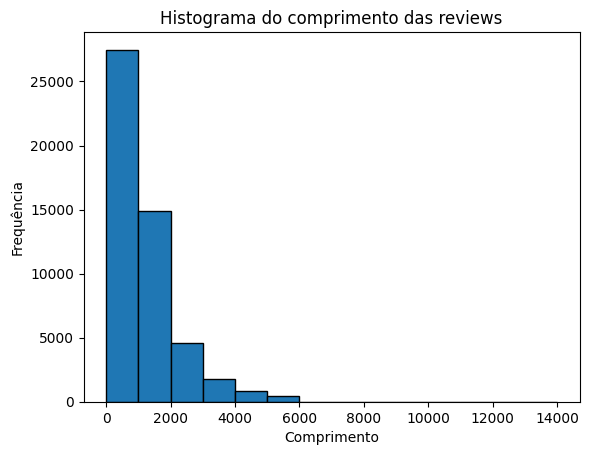

In [3]:
import matplotlib.pyplot as plt

review_len = []
for review in df['review']:
    review_len.append(len(review))

max_len = max(review_len)
bins = range(0, int(max_len) + 1000, 1000)

plt.hist(review_len, bins=bins, edgecolor='black')
plt.title('Histograma do comprimento das reviews')
plt.xlabel('Comprimento')
plt.ylabel('Frequência')
plt.show()

In [6]:
def cap_500(text):
  if len(text) <= 500:
    return text
  return text[:500].rsplit(' ', 1)[0]

df['review'] = df['review'].apply(cap_500)

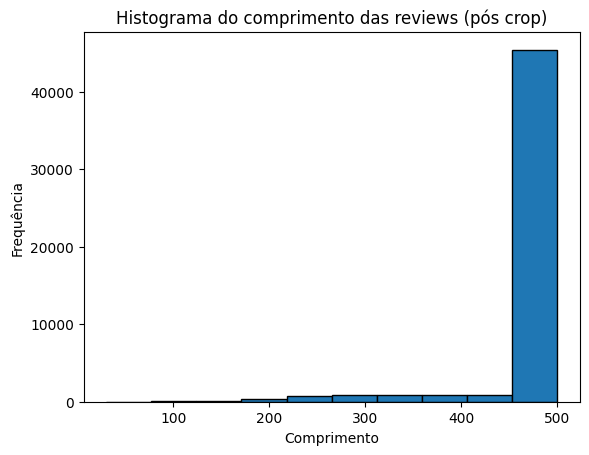

In [8]:
import matplotlib.pyplot as plt

review_len = []
for review in df['review']:
    review_len.append(len(review))

plt.hist(review_len, bins=10, edgecolor='black')
plt.title('Histograma do comprimento das reviews (pós crop)')
plt.xlabel('Comprimento')
plt.ylabel('Frequência')
plt.show()

In [13]:
print(df.iloc[0].review)

one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to


### Remoção de stopwords e lemmatization

In [ ]:
import spacy

#uv run python -m spacy download pt_core_news_sm
nlp = spacy.load("pt_core_news_sm")

def remove_stopwords(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if not token.is_stop])

df['review'] = df['review'].apply(remove_stopwords)

df.head()

OSError: [E050] Can't find model 'pt_core_news_sm'. It doesn't seem to be a Python package or a valid path to a data directory.